<h1>гипотеза</h1>
<p>с увеличением количества фотографий в карточке товара количество заказов не увеличивается.
 посмотрим на распределение количества фотографий, а также на корреляцию между количеством фото и количеством заказов. </p>
<p>Если увеличение количества фотографий не связано с ростом заказов, компании следует сосредоточиться не на количестве изображений, а на их качестве или релевантности отображения товаров в интерфейсе.</p>

<h1>summary исследования</h1>
<p>Не удалось обнаружить значимую зависимость. В ходе исследования удалось выяснить, что ни для всей выборки в целом, ни для отдельных категорий, ни для категорий без особо популярных товаров количество фото не давала прироста числа заказов.</p>

<h3>импорты</h3>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split 
sns.set_theme(style="darkgrid")

In [ ]:
df = pd.read_csv("Brazilian E-Commerce Public Dataset by Olist\prod_orders_items.csv")

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\rur\AppData\Local\Temp\ipykernel_9288\3534856545.py:1: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv("Brazilian E-Commerce Public Dataset by Olist\prod_orders_items.csv")


In [ ]:
df['product_photos_qty'].fillna(0, inplace=True)

C:\Users\rur\AppData\Local\Temp\ipykernel_9288\2042513655.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_photos_qty'].fillna(0, inplace=True)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   product_id             112650 non-null  object 
 1   product_photos_qty     112650 non-null  float64
 2   product_category_name  111047 non-null  object 
 3   order_id               112650 non-null  object 
 4   order_status           112650 non-null  object 
dtypes: float64(1), object(4)
memory usage: 4.3+ MB


<h3>Возьмём случайную выборку из всего ДС</h3>

In [39]:
train_df = df.copy()

<h3> Соотношение количества заказов к количеству фотографий в карточке товара</h3>

<Axes: xlabel='product_photos_qty', ylabel='Count'>

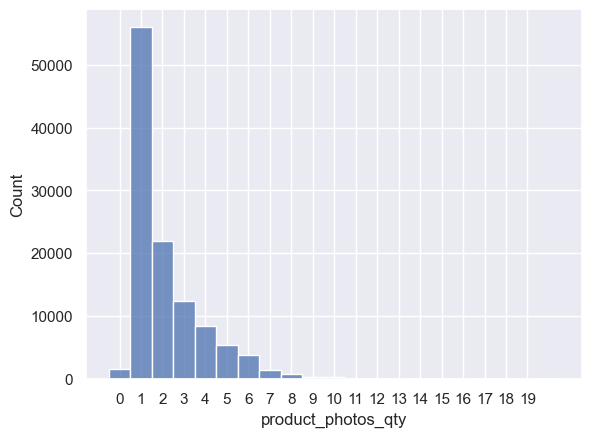

In [40]:
plt.xticks(np.arange(0, 20, 1))
sns.histplot(train_df['product_photos_qty'], bins=30, discrete=True)

<h3> Соотношение количества заказов к количеству фотографий в карточке товара: разбивка по категориям товаров (топ 6)</h3>
<p>по графикам можно увидеть, что в отдельно взятых категориях товаров соотношение количества фотографий к количеству заказов не меняется (это же мы видим без применения фильтров по категориям)</p>
<p>Для оценки вероятной взаимосвязи количества фото в карточке к количеству заказов, я использовал метод Спирмена. Результаты показывают почти полное отсутствие взаимосвязи.</p>
<p>также для проверки влияния "популярности" категории на количество фотографий в карточке я построил графики для 6 наименее популярных категорий (количество заказов от 100). Соотношение не изменилось.</p>

In [32]:
t = train_df.groupby(train_df['product_category_name']).agg(count_of_orders = pd.NamedAgg('order_id', 'count'), med_photos = pd.NamedAgg('product_photos_qty', 'median')).reset_index().sort_values(by='count_of_orders', ascending=False)

In [33]:
t[['med_photos', 'count_of_orders']].corr(method='spearman')

,med_photos,count_of_orders
med_photos,1.000000,-0.081145
count_of_orders,-0.081145,1.000000


<p>топ 6 "лучших"</p>

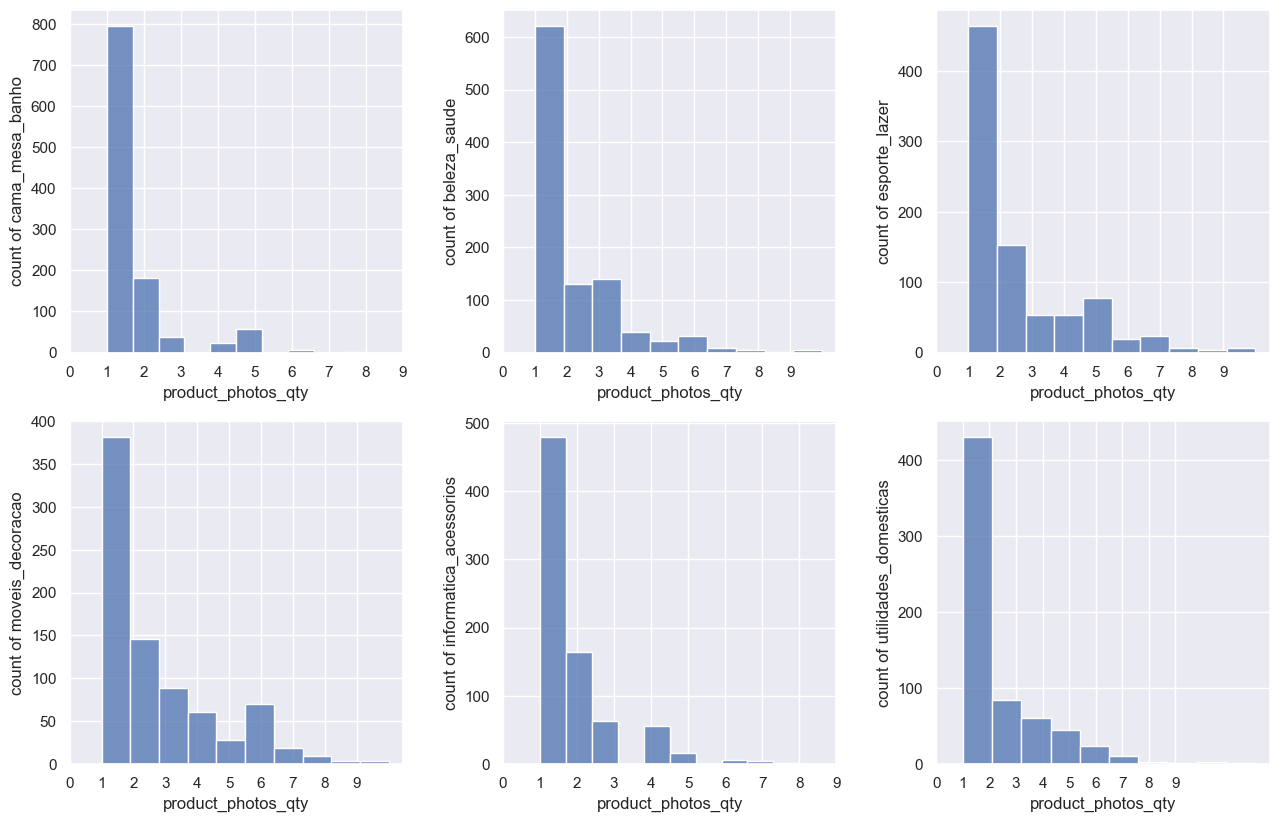

In [27]:
spisok_categ = t[t['count_of_orders'] > 100]['product_category_name'].unique()
k = 10
plt.figure(figsize=(3 * k, 3 * k))

for cata in range(1, 7):
    
    plt.subplot(6, 3, cata)
    
    sns.histplot(train_df['product_photos_qty'][train_df['product_category_name'] == spisok_categ[cata-1]], bins=10).set_ylabel(f'count of {spisok_categ[cata-1]}')
    plt.xticks(np.arange(0, 10, 1))
    plt.subplots_adjust(left=0.5, bottom=0.1, right=0.9, top=0.9,
                    wspace=0.3, hspace=0.2)
    

<p>топ 6 "худших"</p>

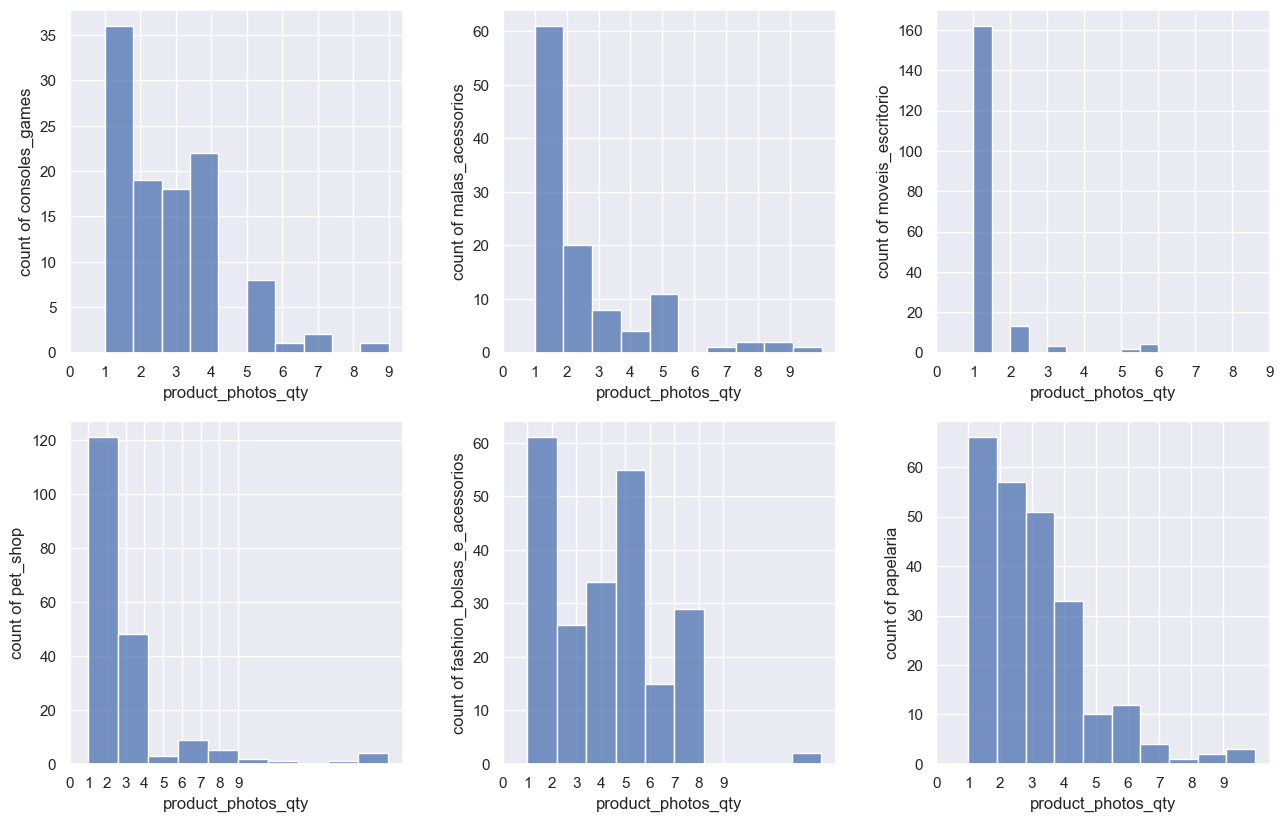

In [9]:
d = t.sort_values(by='count_of_orders', ascending=True)
spisok_categ2 = d[d['count_of_orders'] > 100]['product_category_name'].unique()
k = 10
plt.figure(figsize=(3 * k, 3 * k))

for cata in range(1, 7):
    
    plt.subplot(6, 3, cata)
    
    sns.histplot(train_df['product_photos_qty'][train_df['product_category_name'] == spisok_categ2[cata-1]], bins=10).set_ylabel(f'count of {spisok_categ2[cata-1]}')
    plt.xticks(np.arange(0, 10, 1))
    plt.subplots_adjust(left=0.5, bottom=0.1, right=0.9, top=0.9,
                    wspace=0.3, hspace=0.2)

<h3>проверка гипотезы после удаления товаров с экстремально частым количеством заказов</h3>
<p>после использования группировки по id товара я взял 99 квантиль данных и посмотрел соотношение количества заказов к медианному значению количества фото в карточке товара. Использовав метод Спирмена для вычисления корреляции и визуальное отображение исследуемых показателей, удалось выявить, что количество фото не даёт повышения количество заказов. Резкое повышение графика в одном столбце обусловлено большим количеством фото в отдельно взятом товаре - это не создаёт тренд.</p>
<p>Далее я проверил соотношение медианного числа заказов товара в категории и медианное значение количества фото. Тип графиков не изменился, что говорит нам о том, что как правило количество фото в карточке товара не влияют на количество заказов</p>

In [10]:
g = train_df.groupby(['product_id', 'product_category_name']).agg(count_ord = pd.NamedAgg('order_id','count'), med_photo = pd.NamedAgg('product_photos_qty','median')).reset_index()

In [11]:
g.describe()

,count_ord,med_photo
count,7025.000000,7025.000000
mean,1.579359,2.257367
std,2.181147,1.795443
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,3.000000
max,53.000000,17.000000


In [12]:
g99 = g[g['count_ord'] < g['count_ord'].quantile(0.99)]

In [13]:
g99.describe()

,count_ord,med_photo
count,6951.000000,6951.000000
mean,1.411308,2.256941
std,1.035143,1.794600
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,3.000000
max,9.000000,17.000000


<p>категория товаров, показавшая повышение количества заказов к количеству фото - это игрушки. Если посмотреть на базовые метрики этих товаров, можно увидеть типичную картину для всего датасета</p>

In [34]:
g99_gropped[['med_photo', 'median_ord']].corr(method='spearman')

,med_photo,median_ord
med_photo,1.000000,0.040119
median_ord,0.040119,1.000000


In [14]:
g99[g99['count_ord'] > 5].sort_values(by='med_photo', ascending=False).head(5)

,product_id,product_category_name,count_ord,med_photo
3459,7fab1a1472fdd934397068931f63f3ca,brinquedos,8,10.0
4498,a5341e3f8155dbb3e62323d3ea289729,moveis_decoracao,6,7.0
2318,553e0e7590d3116a072507a3635d2877,cama_mesa_banho,7,5.0
2339,55b71bf300a2765a382eaec566df531f,esporte_lazer,7,5.0
6359,e9a69340883a438c3f91739d14d3a56d,utilidades_domesticas,8,5.0


In [15]:
g99[g99['product_category_name'] == 'brinquedos'].describe()

,count_ord,med_photo
count,285.000000,285.000000
mean,1.431579,2.715789
std,1.141280,1.846179
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,2.000000
75%,1.000000,4.000000
max,9.000000,12.000000


In [16]:
g99[['med_photo', 'count_ord']].corr(method='spearman')

,med_photo,count_ord
med_photo,1.000000,-0.007091
count_ord,-0.007091,1.000000


<Axes: xlabel='med_photo', ylabel='count_ord'>

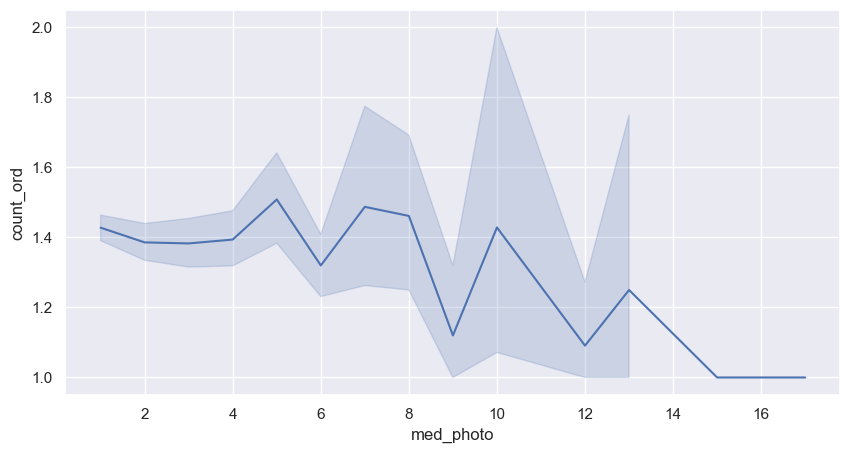

In [38]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=g99,
    x='med_photo',
    y='count_ord'
)

In [18]:
g99_gropped = g99.groupby('product_category_name').agg(median_ord = pd.NamedAgg('count_ord','median'), med_photo = pd.NamedAgg('med_photo','median')).reset_index()

In [19]:
g99_gropped.sort_values(by='median_ord', ascending=False)

,product_category_name,median_ord,med_photo
7,audio,2.0,1.0
52,moveis_colchao_e_estofado,2.0,1.0
60,pc_gamer,2.0,4.0
61,pcs,2.0,4.0
41,flores,2.0,1.0
...,...,...,...
67,sinalizacao_e_seguranca,1.0,1.0
68,tablets_impressao_imagem,1.0,1.0
69,telefonia,1.0,2.0
70,telefonia_fixa,1.0,3.0


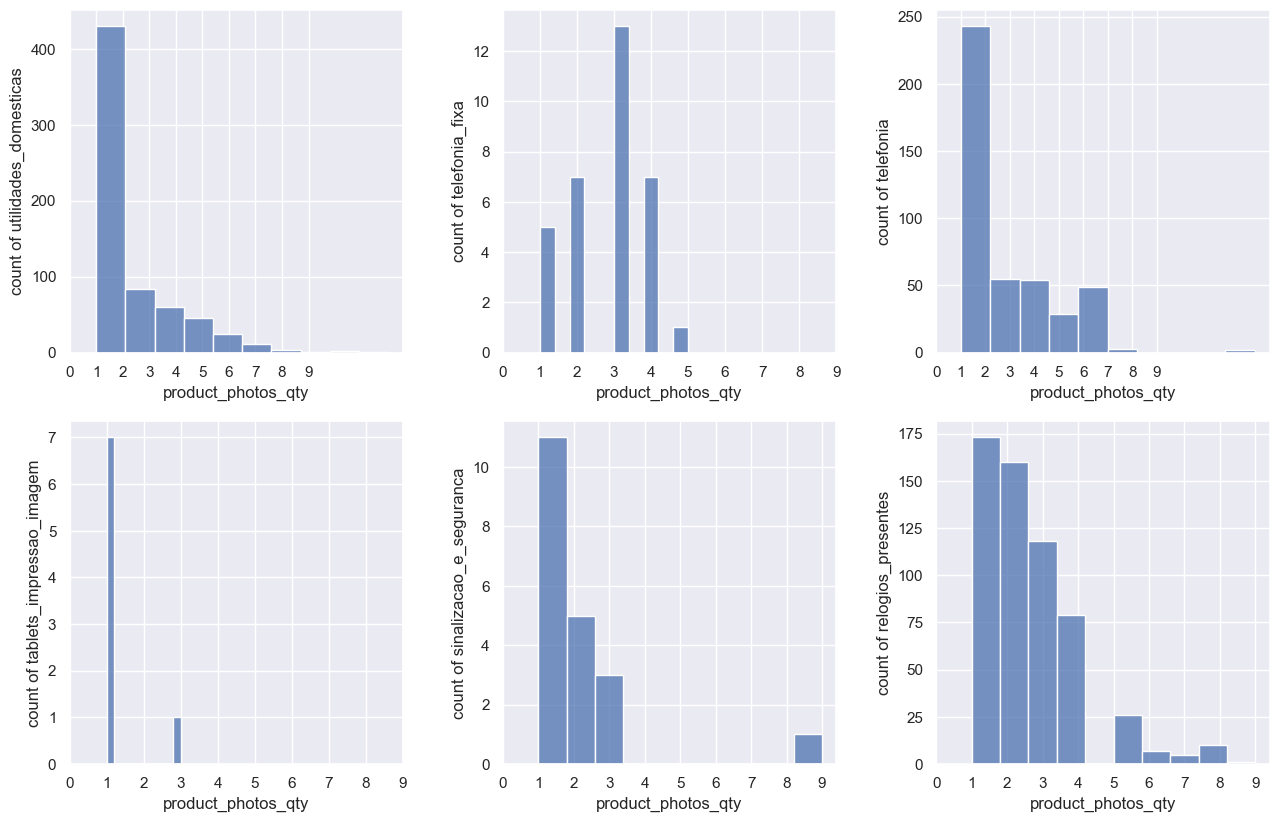

In [20]:
spisok_categ = g99_gropped['product_category_name'].sort_values(ascending=False).unique()
k = 10
plt.figure(figsize=(3 * k, 3 * k))

for cata in range(1, 7):
    
    plt.subplot(6, 3, cata)
    
    sns.histplot(train_df['product_photos_qty'][train_df['product_category_name'] == spisok_categ[cata-1]], bins=10).set_ylabel(f'count of {spisok_categ[cata-1]}')
    plt.xticks(np.arange(0, 10, 1))
    plt.subplots_adjust(left=0.5, bottom=0.1, right=0.9, top=0.9,
                    wspace=0.3, hspace=0.2)
    